# This notebook:
### 1. Extracts DICOM metadata from `train` and `valid` splits.
### 2. Saves a combined DICOM metadata CSV.
### 3. Expands PNGs for patients/studies present in DICOM metadata.
### 4. Saves train/validation PNG CSVs for your pipeline.

In [5]:
# --- Imports ---
import os
import glob
import pandas as pd
import tqdm
import pydicom


In [6]:
# --- Paths ---
dcm_base_root = "../data/dcm_chexpert_plus_chunk_0"  # contains 'train' and 'valid'
png_base_root = "../data/png_chexpert_plus_chunk_0"  # contains 'train' and 'valid'
output_dir = "./"                                    # where to save CSVs
splits = ["train", "valid"]

In [7]:
# ## Step 1: Extract DICOM Metadata

# %%
def clean_value(v):
    """Convert DICOM values to strings"""
    if isinstance(v, list):
        return ";".join(map(str, v))
    if pd.isna(v):
        return ""
    return v

all_records = []

for split in splits:
    base_dir = os.path.join(dcm_base_root, split)
    print(f"Processing DICOMs in {split} folder...")

    for root, _, files in tqdm.tqdm(os.walk(base_dir)):
        for f in files:
            if f.lower().endswith(".dcm"):
                path = os.path.join(root, f)
                try:
                    ds = pydicom.dcmread(path, stop_before_pixels=True)

                    # --- Extract patient and study from relative path ---
                    rel_path = os.path.relpath(path, base_dir)
                    parts = rel_path.split(os.sep)
                    if len(parts) < 3:
                        print(f"Skipping unexpected path: {rel_path}")
                        continue
                    patient_id = parts[0]
                    study_id = parts[1]

                    # --- Extract metadata ---
                    record = {
                        "path": path,
                        "split": split,
                        "patient_id": patient_id,
                        "study_id": study_id
                    }

                    for elem in ds:
                        if elem.VR != "SQ":
                            record[elem.keyword] = clean_value(elem.value)

                    all_records.append(record)
                except Exception as e:
                    print("Failed to read", path, e)

# --- Save DICOM metadata CSV ---
df_all = pd.DataFrame(all_records)
dcm_csv_path = os.path.join(output_dir, "dicom_metadata_all_train_valid.csv")
df_all.to_csv(dcm_csv_path, index=False)
print(f"Saved combined DICOM CSV: {dcm_csv_path} ({len(df_all)} rows)")

Processing DICOMs in train folder...


12178it [00:42, 285.23it/s]


Processing DICOMs in valid folder...


15it [00:00, 615.53it/s]


Saved combined DICOM CSV: ./dicom_metadata_all_train_valid.csv (12566 rows)


In [51]:
# ## Step 2: Expand PNGs for matching DICOMs

# %%
def expand_png_rows(df, png_base_root):
    expanded = []

    for _, row in tqdm.tqdm(df.iterrows(), total=len(df)):
        split = row["split"]
        patient_id = row["patient_id"]
        study_id = row["study_id"]

        png_folder = os.path.join(png_base_root, split, patient_id, study_id)
        if not os.path.exists(png_folder):
            print(f"Warning: PNG folder not found: {png_folder}")
            continue

        png_files = []
        for ext in ["*.png", "*.PNG", "*.jpg", "*.jpeg", "*.JPG", "*.JPEG"]:
            png_files.extend(glob.glob(os.path.join(png_folder, ext)))

        if len(png_files) == 0:
            print(f"Warning: No PNGs in folder: {png_folder}")
            continue

        for pf in png_files:
            entry = row.to_dict()
            entry["png_path"] = pf
            entry["dcm_path"] = row["path"]
            expanded.append(entry)

    return pd.DataFrame(expanded)

# %%
expanded_list = []

for split in splits:
    df_split = df_all[df_all["split"]==split].reset_index(drop=True)
    expanded_split = expand_png_rows(df_split, png_base_root)
    expanded_list.append(expanded_split)

expanded_df = pd.concat(expanded_list, ignore_index=True)
print("Total PNG-level samples:", len(expanded_df))
expanded_df.head()

  0%|          | 0/12559 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 440.23it/s]


Total PNG-level samples: 16148


,path,split,patient_id,study_id,Manufacturer,BodyPartExamined,RelativeXRayExposure,ViewPosition,Laterality,SamplesPerPixel,...,ExposureControlModeDescription,ImageLaterality,WindowCenter,WindowWidth,PresentationLUTShape,ExposuresOnPlate,,ExposureTime,png_path,dcm_path
0,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study3,Agfa,CHEST,124.0,AP,,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
1,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,352.0,AP,NaN,1,...,,U,"[4033, 4033, 4033]","[3395, 2546, 5092]",IDENTITY,NaN,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
2,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,352.0,AP,NaN,1,...,,U,"[4033, 4033, 4033]","[3395, 2546, 5092]",IDENTITY,NaN,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
3,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,549.0,LL,NaN,1,...,CENTRAL_ION_CHAMBER_CELL,U,"[4810, 4810, 4810]","[3486, 2615, 5230]",IDENTITY,NaN,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
4,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,549.0,LL,NaN,1,...,CENTRAL_ION_CHAMBER_CELL,U,"[4810, 4810, 4810]","[3486, 2615, 5230]",IDENTITY,NaN,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...


In [52]:
# Save to CSV
expanded_csv_path = os.path.join(output_dir, "expanded_metadata_all_train_valid.csv")
expanded_df.to_csv(expanded_csv_path, index=False)

### Clean Extended df

In [63]:
# Load the expanded CSV to verify
expanded_df = pd.read_csv(expanded_csv_path)
print("Expanded CSV loaded:", expanded_df.shape)
expanded_df.head()

Expanded CSV loaded: (16148, 38)


,path,split,patient_id,study_id,Manufacturer,BodyPartExamined,RelativeXRayExposure,ViewPosition,Laterality,SamplesPerPixel,...,ExposureControlModeDescription,ImageLaterality,WindowCenter,WindowWidth,PresentationLUTShape,ExposuresOnPlate,Unnamed: 34,ExposureTime,png_path,dcm_path
0,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study3,Agfa,CHEST,124.0,AP,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
1,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,352.0,AP,NaN,1,...,NaN,U,"[4033, 4033, 4033]","[3395, 2546, 5092]",IDENTITY,NaN,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
2,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,352.0,AP,NaN,1,...,NaN,U,"[4033, 4033, 4033]","[3395, 2546, 5092]",IDENTITY,NaN,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
3,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,549.0,LL,NaN,1,...,CENTRAL_ION_CHAMBER_CELL,U,"[4810, 4810, 4810]","[3486, 2615, 5230]",IDENTITY,NaN,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
4,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,549.0,LL,NaN,1,...,CENTRAL_ION_CHAMBER_CELL,U,"[4810, 4810, 4810]","[3486, 2615, 5230]",IDENTITY,NaN,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...


In [64]:
# Percentaeg of missing values per column
missing_percent = expanded_df.isna().mean() * 100
print("Percentage of missing values per column:")
print(missing_percent.sort_values(ascending=False))

Percentage of missing values per column:
Unnamed: 34                       99.993807
ExposureTime                      99.993807
Laterality                        98.984394
ExposureIndex                     93.726777
TargetExposureIndex               93.726777
ImageLaterality                   76.275700
ExposuresOnPlate                  74.083478
ExposureControlModeDescription    68.900173
ExposureControlMode               68.658657
WindowWidth                       66.187763
WindowCenter                      66.187763
XRayTubeCurrent                   63.574436
ExposureInuAs                     63.574436
PresentationLUTShape              61.345058
Exposure                          37.719841
KVP                               37.719841
RelativeXRayExposure              31.520931
PixelSpacing                      31.341343
BurnedInAnnotation                25.854595
path                               0.000000
split                              0.000000
patient_id                         

In [65]:
# Select only columsn with less than 50% missing values
threshold = 5
cols_to_keep = missing_percent[missing_percent < threshold].index.tolist()
print(f"Keeping {len(cols_to_keep)} columns with less than {threshold}% missing values.")
expanded_df = expanded_df[cols_to_keep]

expanded_df

Keeping 19 columns with less than 5% missing values.


,path,split,patient_id,study_id,Manufacturer,BodyPartExamined,ViewPosition,SamplesPerPixel,PhotometricInterpretation,Rows,Columns,BitsAllocated,BitsStored,PixelRepresentation,RescaleIntercept,RescaleSlope,RescaleType,png_path,dcm_path
0,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study3,Agfa,CHEST,AP,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
1,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,AP,1,MONOCHROME2,2012,2012,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
2,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,AP,1,MONOCHROME2,2012,2012,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
3,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,LL,1,MONOCHROME2,2021,2021,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
4,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE Healthcare,CHEST,LL,1,MONOCHROME2,2021,2021,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16143,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64680,study1,Agfa-Gevaert AG,CHEST,AP,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16144,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64643,study1,Agfa-Gevaert AG,CHEST,AP,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16145,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64678,study1,Agfa-Gevaert AG,CHEST,AP,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16146,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64592,study1,Agfa-Gevaert AG,CHEST,AP,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...


### Stadardize manufacturer names 

In [66]:
# Print manufacturer distribution
if "Manufacturer" in expanded_df.columns:
    print("Manufacturer distribution:")
    print(expanded_df["Manufacturer"].value_counts())
    
# There are different names for the same manufactruer
# Build a mapping to unify them
manufacturer_mapping = {
    "Agfa": "AGFA",
    "Agfa-Gevaert AG": "AGFA",
    "GE MEDICAL SYSTEMS": "GE",
    '"GE Healthcare"': "GE",
    "GE Healthcare": "GE",}

if "Manufacturer" in expanded_df.columns:
    expanded_df["Manufacturer"] = expanded_df["Manufacturer"].replace(manufacturer_mapping)
    print("Unified Manufacturer distribution:")
    print(expanded_df["Manufacturer"].value_counts())
    
expanded_df

Manufacturer distribution:
Manufacturer
Agfa                  6908
Agfa-Gevaert AG       3717
GE MEDICAL SYSTEMS    3548
"GE Healthcare"       1353
AGFA                   458
GE Healthcare          160
Varian                   4
Name: count, dtype: int64
Unified Manufacturer distribution:
Manufacturer
AGFA      11083
GE         5061
Varian        4
Name: count, dtype: int64


,path,split,patient_id,study_id,Manufacturer,BodyPartExamined,ViewPosition,SamplesPerPixel,PhotometricInterpretation,Rows,Columns,BitsAllocated,BitsStored,PixelRepresentation,RescaleIntercept,RescaleSlope,RescaleType,png_path,dcm_path
0,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study3,AGFA,CHEST,AP,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
1,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,AP,1,MONOCHROME2,2012,2012,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
2,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,AP,1,MONOCHROME2,2012,2012,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
3,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,LL,1,MONOCHROME2,2021,2021,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
4,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,LL,1,MONOCHROME2,2021,2021,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16143,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64680,study1,AGFA,CHEST,AP,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16144,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64643,study1,AGFA,CHEST,AP,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16145,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64678,study1,AGFA,CHEST,AP,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16146,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64592,study1,AGFA,CHEST,AP,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...


### Standardize view position

In [67]:
if "ViewPosition" in expanded_df.columns:
    print("ViewPosition distribution:")
    print(expanded_df["ViewPosition"].value_counts())
    
# Encode ViewPosition as binary: AP=0, PA=1, LL= 2, RL = 3
if "ViewPosition" in expanded_df.columns:
    view_mapping = {"AP": 0, "PA": 1, "LL": 2, "RL": 3}
    expanded_df["ViewPosition"] = expanded_df["ViewPosition"].map(view_mapping)
    
expanded_df

ViewPosition distribution:
ViewPosition
AP    10370
PA     2979
LL     2781
RL       18
Name: count, dtype: int64


,path,split,patient_id,study_id,Manufacturer,BodyPartExamined,ViewPosition,SamplesPerPixel,PhotometricInterpretation,Rows,Columns,BitsAllocated,BitsStored,PixelRepresentation,RescaleIntercept,RescaleSlope,RescaleType,png_path,dcm_path
0,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study3,AGFA,CHEST,0,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
1,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,0,1,MONOCHROME2,2012,2012,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
2,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,0,1,MONOCHROME2,2012,2012,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
3,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,2,1,MONOCHROME2,2021,2021,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
4,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,2,1,MONOCHROME2,2021,2021,16,14,0,0.0,1.0,US,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16143,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64680,study1,AGFA,CHEST,0,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16144,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64643,study1,AGFA,CHEST,0,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16145,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64678,study1,AGFA,CHEST,0,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16146,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64592,study1,AGFA,CHEST,0,1,MONOCHROME1,2320,2828,16,12,0,0.0,1.0,LOG_E REL,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...


AP = ANTERIOR-POSTERIOR, PA = POSTERIOR, ANTERIOR, LL = LEFT LATERAL, RL = RIGHT LATERAL

In [58]:
if "Laterality" in expanded_df.columns:
    print("Laterality distribution:")
    print(expanded_df["Laterality"].value_counts())

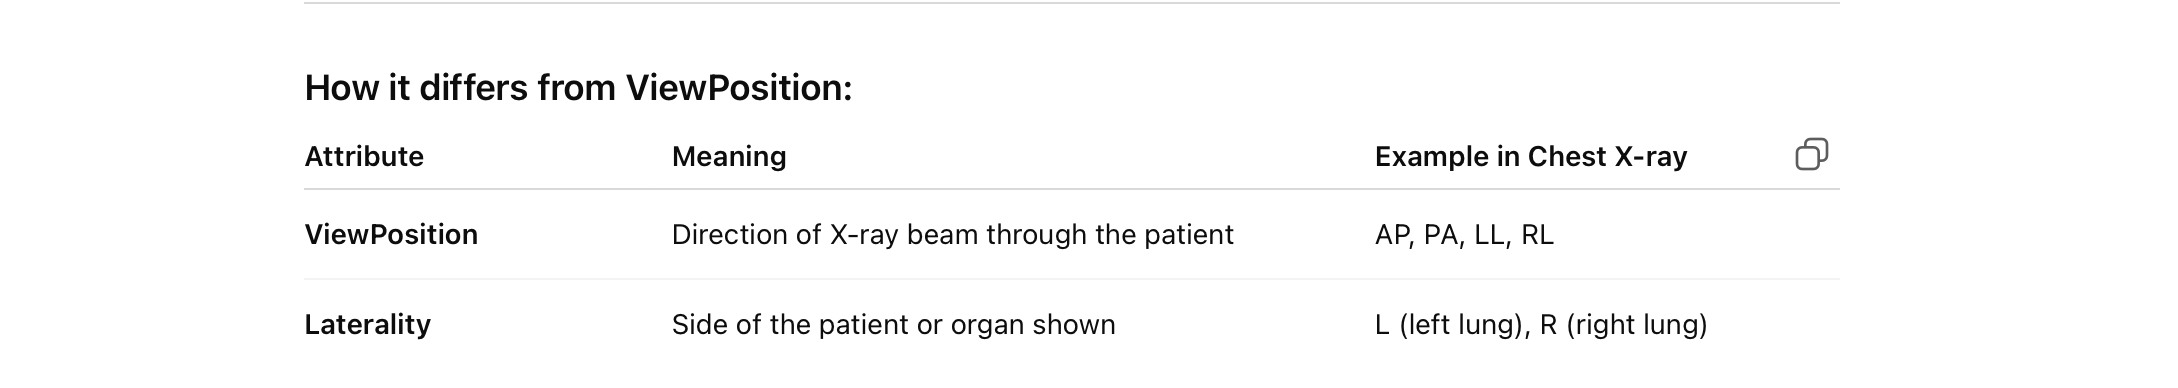

### PhotometricInterpretation
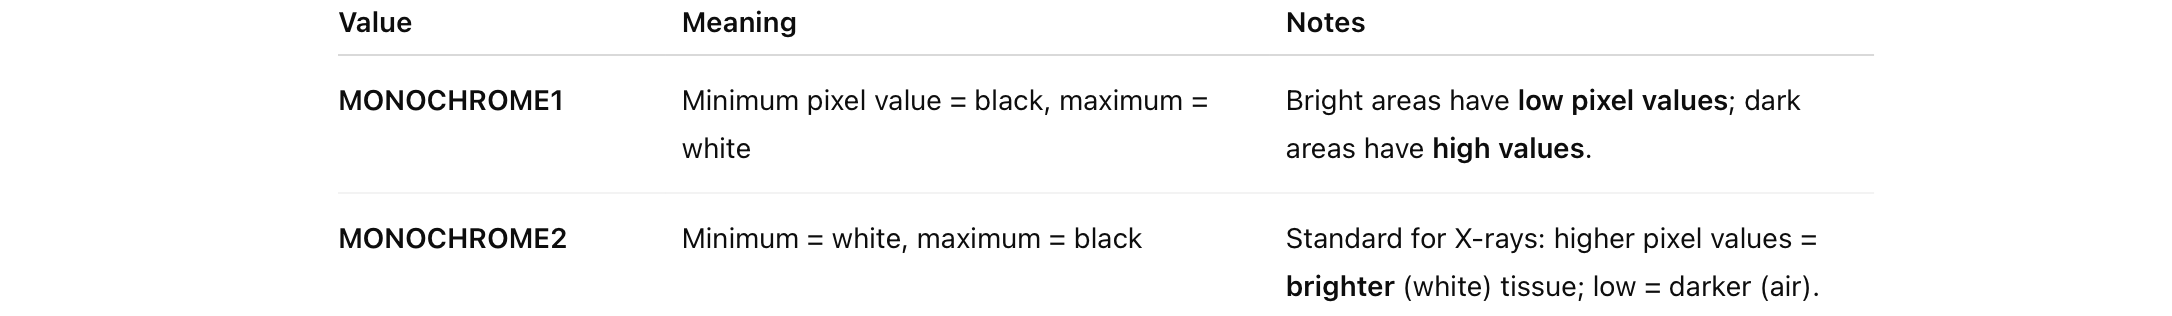

In [59]:
if "PhotometricInterpretation" in expanded_df.columns:
    print("PhotometricInterpretation distribution:")
    print(expanded_df["PhotometricInterpretation"].value_counts())
    
# Encode PhotometricInterpretation as binary: MONOCHROME1=0, MONOCHROME2=1
if "PhotometricInterpretation" in expanded_df.columns:
    expanded_df["PhotometricInterpretation"] = expanded_df["PhotometricInterpretation"].map({"MONOCHROME1": 0, "MONOCHROME2": 1})
    
expanded_df

PhotometricInterpretation distribution:
PhotometricInterpretation
MONOCHROME1    11085
MONOCHROME2     5063
Name: count, dtype: int64


,path,split,patient_id,study_id,Manufacturer,BodyPartExamined,RelativeXRayExposure,ViewPosition,SamplesPerPixel,PhotometricInterpretation,...,BitsStored,PixelRepresentation,BurnedInAnnotation,RescaleIntercept,RescaleSlope,RescaleType,KVP,Exposure,png_path,dcm_path
0,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study3,AGFA,CHEST,124.0,0,1,0,...,12,0,NO,0.0,1.0,LOG_E REL,NaN,NaN,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
1,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,352.0,0,1,1,...,14,0,NO,0.0,1.0,US,91.0,3.0,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
2,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,352.0,0,1,1,...,14,0,NO,0.0,1.0,US,91.0,3.0,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
3,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,549.0,2,1,1,...,14,0,NO,0.0,1.0,US,120.0,12.0,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
4,../data/dcm_chexpert_plus_chunk_0/train/patien...,train,patient21391,study13,GE,CHEST,549.0,2,1,1,...,14,0,NO,0.0,1.0,US,120.0,12.0,../data/png_chexpert_plus_chunk_0/train/patien...,../data/dcm_chexpert_plus_chunk_0/train/patien...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16143,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64680,study1,AGFA,CHEST,NaN,0,1,0,...,12,0,NaN,0.0,1.0,LOG_E REL,0.0,0.0,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16144,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64643,study1,AGFA,CHEST,NaN,0,1,0,...,12,0,NaN,0.0,1.0,LOG_E REL,0.0,0.0,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16145,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64678,study1,AGFA,CHEST,NaN,0,1,0,...,12,0,NaN,0.0,1.0,LOG_E REL,0.0,0.0,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...
16146,../data/dcm_chexpert_plus_chunk_0/valid/patien...,valid,patient64592,study1,AGFA,CHEST,NaN,0,1,0,...,12,0,NaN,0.0,1.0,LOG_E REL,0.0,0.0,../data/png_chexpert_plus_chunk_0/valid/patien...,../data/dcm_chexpert_plus_chunk_0/valid/patien...


---

In [ ]:
# ## Step 3: Split into train / validation CSVs

# %%
train_df = expanded_df[expanded_df["split"]=="train"].reset_index(drop=True)
val_df   = expanded_df[expanded_df["split"]=="valid"].reset_index(drop=True)

train_csv = os.path.join(output_dir, "train_metadata_png.csv")
val_csv   = os.path.join(output_dir, "val_metadata_png.csv")

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)

print(f"Train CSV saved: {train_csv} ({len(train_df)} samples)")
print(f"Validation CSV saved: {val_csv} ({len(val_df)} samples)")



Train CSV saved: ./train_metadata_png.csv (16141 samples)
Validation CSV saved: ./val_metadata_png.csv (7 samples)
